# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Beshair-Khan/flyrank_ml_internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract

Content teams need a way to know which webpages are likely to lose traffic before it happens, not after. This project builds a machine learning model that predicts whether a webpage's search performance will grow, decline, or stay stable, using one month of page level search and engagement data from FlyRank's internship warehouse. We compared a simple hand written threshold rule against a Decision Tree, Random Forest, and XGBoost, evaluating each on precision@50 measuring how often the model's top ranked "Declining" predictions were correct. The hand rule failed completely (0% precision), while a weighted XGBoost model reached 68% precision@50 and correctly identified 51% of all truly declining pages, a substantial improvement after we found and corrected a class imbalance problem in the model's initial results. The final model outputs a ranked, decision support recommendation list, not a verdict it is intended to help content teams prioritize which pages to review first.

## 1. Question

*The research question and the decision it supports.*

We are trying to predict whether a webpage's performance will grow, decline, or stay stable, so an SEO/content team can decide which pages to review first. If we miss a page that's about to decline, the team loses traffic without knowing and if we flag too many stable pages as risky, the team wastes review time. There might be multiple factors that are making a declined webpage and a simple hand rule can't guess all of them and might miss some also it will take so much time that's why we are using a ML model instead of hand written straightforward rules

In [1]:
target_result=['Growing','Declining','Stable']
model_type='Ranking'
evaluation_metric='precision@k'
print(f"Our target result will tell us the status of our webpage such as {target_result[0]}, {target_result[1]}, or {target_result[2]} ")
print(f"We will be using {model_type} method with the {evaluation_metric} as evaluation metrics")

Our target result will tell us the status of our webpage such as Growing, Declining, or Stable 
We will be using Ranking method with the precision@k as evaluation metrics


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

For this project we have used `FlyRank/internship-warehouse's` mid panel `month march 2026` data from `fact_content_daily_performance` folder. After initial inspection we found that we have nearly `9.9M` rows and `30` columns in that data.
We found that almost 31% data in `ga4_data_available` is missing, exactly the rows where `client_has_ga4` is `False`. It shows that almost `31%` client don't have ga4(on-page behavior), also GSC data(search visibility) has its separate missingness in `gsc_avg_position ` column, almost `6.2M` rows has missing values which makes almost `63.30%` missing data from all rows, way more than `ga4_data_available`. 

In [2]:
import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv

load_dotenv()
hf_token = os.getenv('HF_TOKEN')
df_march = pd.read_parquet("hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/",storage_options={"token": hf_token})
df_april=pd.read_parquet("hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/",storage_options={"token": hf_token})

In [3]:
# Inspecting March's Data
print(df_march.shape)
print(df_march['report_date'].min(), df_march['report_date'].max())
print(df_march.columns.tolist())
df_march.head()

(9841378, 30)
2026-03-01 2026-03-31
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events']


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,None,20,0,67,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,None,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,None,125,1,616,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,None,7,0,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,None,11,0,25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Inspecting April's Data
print(df_april.shape)
print(df_april['report_date'].min(), df_april['report_date'].max())
print(df_april.columns.to_list())
df_april.head()

(10424730, 30)
2026-04-01 2026-04-30
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events']


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2026-04-01,client_62f4a7e64f5e0096,content_143987cfdeaba4c0,True,False,True,None,9,0,493,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-01,client_62f4a7e64f5e0096,content_13a8105125458098,True,False,True,None,1,0,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-01,client_62f4a7e64f5e0096,content_6a887d56ab6c8362,True,False,False,None,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-01,client_62f4a7e64f5e0096,content_e2bd76be7eed690d,True,False,True,None,1,0,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-01,client_62f4a7e64f5e0096,content_ddbfb1907979759a,True,False,False,None,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Percentage of null values in March
print("Percentage of Null values in March")
print(df_march.isna().sum()/len(df_march)*100)
# Percentage of Null values in April
print("\nPercentage of Null values in April")
print(df_april.isna().sum()/len(df_april)*100)

Percentage of Null values in March
report_date                  0.000000
client_hash_id               0.000000
content_hash_id              0.000000
client_has_gsc               0.000000
client_has_ga4               0.000000
gsc_data_available           0.000000
ga4_data_available          30.673967
gsc_impressions              0.000000
gsc_clicks                   0.000000
gsc_sum_position             0.000000
gsc_avg_position            63.307364
ga4_pageviews               30.673967
ga4_sessions                30.673967
ga4_users                   30.673967
ga4_engaged_sessions        30.673967
ga4_total_engagement_sec    30.673967
sessions_organic            30.673967
sessions_direct             30.673967
sessions_referral           30.673967
sessions_social             30.673967
sessions_paid               30.673967
sessions_ai                 30.673967
ai_chatgpt                  30.673967
ai_perplexity               30.673967
ai_gemini                   30.673967
ai_copilot     

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

We will use following threshold to call something "Growing", "Stable" , and "Declining" based on gsc_clicks from both month's data `March` and `April`:
- Growth = above +15%
- Declining = below -10%
- Stable= Between -10% and +15%

We made it asymmetric intentionally because declining pages needs to be catch earlier before it causes some major problems. The cost of late detection of declining pages is more than that of observing growth patterns.
But for the rows where `March_clicks` is `0` we cannot calculate percentage to deermine whether the age is growing, declining or remaining stable that's why for those rows the percentage will not be calculated. To solve this problem we will split dataset into two parts one where `march-clicks` is 0 and other where `march_clicks` is greater than 0. 
- If both columns `march_clicks` and `april_cicks` contain 0 then the page is neither growing nor declining but staying stable in this case the label would be `Stable`.
- If `march_clicks` contains 0 and `april_cicks`is greater than 0 then the page is growing in this case the label would be `Growing`.
- For this group label `Declining` is impossible as `gsc_clicks` can't be lower than 0.

In [6]:
# Sum of GSC clicks per page from both months
march_sum=df_march.groupby('content_hash_id')['gsc_clicks'].sum()
april_sum=df_april.groupby('content_hash_id')['gsc_clicks'].sum()
# Converting both groups to dataframes
march=pd.DataFrame(march_sum).reset_index()
april=pd.DataFrame(april_sum).reset_index()

In [7]:
# Merging both dataframes
df=pd.merge(march,april,on='content_hash_id',how='inner')
# renaming columns
df=df.rename(columns={
    'gsc_clicks_x': 'march_clicks',
    'gsc_clicks_y': 'april_clicks'
})
df.head()

,content_hash_id,march_clicks,april_clicks
0,content_000005d4ced12088,0,0
1,content_00001e488b74b799,0,0
2,content_00007bd2985b77c3,0,0
3,content_00008950670cb6b5,0,0
4,content_0000a348850eb1fc,0,0


In [8]:
print(march['content_hash_id'].nunique())
print(april['content_hash_id'].nunique())
print(df['content_hash_id'].nunique())

331437
362172
331436


The above result compares number of unique values in `March`, `April`, and merged data `df`. It shows that `March` had `331437` unique values whereas `April` had `362172` unique values, almost `30,700` more numbers than `March` means new pages were added in `April` . We explicitely removed those unmatched values from our merged data since they lack a March baseline for comparison

In [9]:
equal_to_zero=df['march_clicks']==0
df_zero=df[equal_to_zero].copy()
more_than_zero=df['march_clicks']>0
df_nonzero=df[more_than_zero].copy()
print(df_zero.shape)
print(df_nonzero.shape)

(262599, 3)
(68837, 3)


In [10]:
# assigning labels to rows where march_clicks are zero
df_zero['label'] = np.where((df_zero['march_clicks'] == 0) & (df_zero['april_clicks'] == 0), 'Stable', 'Growing')
df_zero['label'].value_counts()

label
Stable     248133
Growing     14466
Name: count, dtype: int64

In [11]:
df_nonzero['pct_change']=(df_nonzero['april_clicks']-df_nonzero['march_clicks'])/df_nonzero['march_clicks']
conditions=[df_nonzero['march_clicks'] < 10,df_nonzero['pct_change']>0.15, df_nonzero['pct_change']<-0.10]
choices=['Low Volume','Growing','Declining']
df_nonzero['label']=np.select(conditions,choices,default='Stable')
df_nonzero['label'].value_counts()

label
Low Volume    50911
Declining     10497
Growing        4700
Stable         2729
Name: count, dtype: int64

In [12]:
print(df_nonzero['march_clicks'].describe())
df_nonzero["march_clicks"].value_counts().sort_index().head(20)

count    68837.000000
mean        11.938812
std         41.790389
min          1.000000
25%          1.000000
50%          3.000000
75%         10.000000
max       5668.000000
Name: march_clicks, dtype: float64


march_clicks
1     20728
2      9421
3      5822
4      4048
5      3114
6      2490
7      2127
8      1678
9      1483
10     1259
11     1071
12      980
13      860
14      731
15      675
16      680
17      542
18      530
19      498
20      419
Name: count, dtype: int64

The above description of `march_clicks` column shows that there is a huge difference in number of clicks for example, a page going from 1 to 2 clicks shows as +100% growth, and a page going from 3 to 1 click shows as -66% decline, even though these are just small, noisy fluctuations rather than real trends. Because of this, we set a minimum volume cutoff of 10 `march_clicks` before applying our percentage-based thresholds. Pages below this cutoff `(march_clicks > 0 and < 10)` are assigned a separate label, `Low Volume`, instead of being forced into Growing, Stable, or Declining.

In [13]:
df_final=pd.concat([df_zero,df_nonzero],ignore_index=True)
print(df_final.shape)
df_final['label'].value_counts()

(331436, 5)


label
Stable        250862
Low Volume     50911
Growing        19166
Declining      10497
Name: count, dtype: int64

In [14]:
df_final['label'].value_counts()*100/len(df_final['label'])

label
Stable        75.689424
Low Volume    15.360733
Growing        5.782715
Declining      3.167127
Name: count, dtype: float64

In above code we finally concatenate our `df_zero` and `df_nonzero` datasets together in final `df_final` dataset with clean labels (Low Volume, Stable, Growing, and Declining). The results shows that almost `75.6%` data is `Stable` it is because mostly rows in `march_clicks` and `april_clicks` contains 0 which makes the data `Stable`.

In [15]:
feat=df_march.groupby('content_hash_id').agg({
    'gsc_impressions':'sum', 
    'ga4_pageviews': 'sum',
    'scroll_events':'sum',
    'client_has_ga4':'mean'
}).reset_index()
feat=feat.rename(columns={'client_has_ga4':'ga4_availability_pct'})
feat.head()

,content_hash_id,gsc_impressions,ga4_pageviews,scroll_events,ga4_availability_pct
0,content_000005d4ced12088,86,0.0,0.0,1.000000
1,content_00001e488b74b799,0,0.0,0.0,1.000000
2,content_00007bd2985b77c3,47,0.0,0.0,0.354839
3,content_00008950670cb6b5,0,2.0,1.0,1.000000
4,content_0000a348850eb1fc,0,1.0,1.0,0.793103


While building features, we discovered that `client_has_ga4` isn't always constant for a page across March. For example, one client's GA4 tracking only started partway through the month (around March 21), so earlier rows showed `False` with no GA4 data, and later rows showed `True` with real, measured values. This meant a simple first value flag would arbitrarily pick either state and hide the fact that GA4 availability changed mid month for these pages.

To handle this properly, we created `ga4_availability_pct`, the percentage of March days where `client_has_ga4` was `True` for each page. This gives the model a sense of how much to trust that page's `ga4_pageviews` and `scroll_events` totals: a low percentage means GA4 was barely running that month, so a low sum likely reflects missing data rather than genuinely low engagement.

In [16]:
df_mod=pd.merge(df_final,feat,on='content_hash_id',how='left')
print(df_mod.shape)
print(df_mod.isna().sum())

(331436, 9)
content_hash_id              0
march_clicks                 0
april_clicks                 0
label                        0
pct_change              262599
gsc_impressions              0
ga4_pageviews                0
scroll_events                0
ga4_availability_pct         0
dtype: int64


Merged feature table into labeled dataset, confirmed row count unchanged and no unexpected missing value

In [17]:
client=df_march.groupby('content_hash_id').agg({
    'client_hash_id':'first'
}).reset_index()
client.head()

,content_hash_id,client_hash_id
0,content_000005d4ced12088,client_9958f0a7ae1df715
1,content_00001e488b74b799,client_625b6439094e23e4
2,content_00007bd2985b77c3,client_73cda7b4e4f265ea
3,content_00008950670cb6b5,client_def0955f7a377868
4,content_0000a348850eb1fc,client_3ffa76342f366962


In [18]:
df_march.groupby('content_hash_id')['client_hash_id'].nunique().max()

np.int64(1)

In [19]:
final_table=pd.merge(df_mod,client,on='content_hash_id',how='left')
print(final_table.shape)
print(final_table.isna().sum())

(331436, 10)
content_hash_id              0
march_clicks                 0
april_clicks                 0
label                        0
pct_change              262599
gsc_impressions              0
ga4_pageviews                0
scroll_events                0
ga4_availability_pct         0
client_hash_id               0
dtype: int64


In [20]:
final_table.head()

,content_hash_id,march_clicks,april_clicks,label,pct_change,gsc_impressions,ga4_pageviews,scroll_events,ga4_availability_pct,client_hash_id
0,content_000005d4ced12088,0,0,Stable,NaN,86,0.0,0.0,1.000000,client_9958f0a7ae1df715
1,content_00001e488b74b799,0,0,Stable,NaN,0,0.0,0.0,1.000000,client_625b6439094e23e4
2,content_00007bd2985b77c3,0,0,Stable,NaN,47,0.0,0.0,0.354839,client_73cda7b4e4f265ea
3,content_00008950670cb6b5,0,0,Stable,NaN,0,2.0,1.0,1.000000,client_def0955f7a377868
4,content_0000a348850eb1fc,0,0,Stable,NaN,0,1.0,1.0,0.793103,client_3ffa76342f366962


Merged client_hash_id into the feature/label table (df_mod as base, to preserve the 331,436 rows labeled dataset), confirmed row count and no unexpected nulls.

In [21]:
from sklearn.model_selection import GroupShuffleSplit

X=final_table[['gsc_impressions', 'ga4_pageviews', 'scroll_events', 'ga4_availability_pct']]
y=final_table['label']
groups=final_table['client_hash_id']
gsc=GroupShuffleSplit(n_splits=1,test_size=0.2, random_state=42)
train_idx,test_idx=next(gsc.split(X,y,groups))
X_test=X.loc[test_idx]
X_train=X.loc[train_idx]
y_test=y.loc[test_idx]
y_train=y.loc[train_idx]
groups_train=groups.loc[train_idx]
groups_test=groups.loc[test_idx]

In [22]:
s1=set(groups_train)
s2=set(groups_test)
s1.intersection(s2)

set()

We first grouped our entire dataframe by `client_hash_id`, and then specifically used `GroupShuffleSplit` to split our data into train/test parts so that no group overlaps each other this method prevents group leakage in training part. To ensure and validate that no client appears in both test and train part we created two sets `s1` and `s2` and then checked their intersection which results in an empty set ensured that no group appears in both parts.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Hand Rule

In [23]:
X_train['gsc_impressions'].describe()

count    300879.000000
mean        848.937294
std        3882.180655
min           0.000000
25%           0.000000
50%           2.000000
75%         204.000000
max      244931.000000
Name: gsc_impressions, dtype: float64

In [24]:
cond=[X_test['gsc_impressions']<20,X_test['gsc_impressions']>20]
choice=['Declining','Growing']
hand_rule_preds=np.select(cond,choice,default='Stable')
hand_rule_preds

array(['Declining', 'Growing', 'Growing', ..., 'Growing', 'Growing',
       'Growing'], shape=(30557,), dtype='<U9')

In [25]:
pd.Series(hand_rule_preds).value_counts()

Declining    17301
Growing      13182
Stable          74
Name: count, dtype: int64

In [26]:
d=pd.DataFrame({'content_hash_id':final_table.loc[X_test.index, 'content_hash_id'],'client_hash_id':final_table.loc[X_test.index, 'client_hash_id'],'gsc_impressions': X_test['gsc_impressions'], 'hand_rule_preds' : hand_rule_preds, 'actual': y_test})
d_sorted=d.sort_values(by='gsc_impressions',ascending=True)
top_50=d_sorted.head(50)
top_50

,content_hash_id,client_hash_id,gsc_impressions,hand_rule_preds,actual
124,content_001fcddc1edfebe2,client_2b4306c3ed003f01,0,Declining,Stable
303,content_004c817aceab7e82,client_8ae2bfb5aa1ffa1e,0,Declining,Stable
226712,content_dd37c64aee55dafc,client_157ffe4d4a595515,0,Declining,Stable
265,content_0042ae1aee6b04d6,client_2b4306c3ed003f01,0,Declining,Stable
226696,content_dd32819cec5cea54,client_2b4306c3ed003f01,0,Declining,Stable
240,content_003d76b6bd07ce93,client_2b4306c3ed003f01,0,Declining,Stable
238,content_003d441c7b6b93d8,client_2b4306c3ed003f01,0,Declining,Stable
234,content_003ad93e7aa59636,client_2b4306c3ed003f01,0,Declining,Stable
233,content_003ad1ab1203912c,client_2b4306c3ed003f01,0,Declining,Stable
166598,content_a2896eb7eddb86fc,client_2b4306c3ed003f01,0,Declining,Stable


In [27]:
top_50['actual'].value_counts()

actual
Stable     46
Growing     4
Name: count, dtype: int64

For the hand rule, we labeled pages as Declining, Growing, or Stable based on a simple threshold: `gsc_impressions < 20` then Declining, `> 20` then Growing, else Stable. Since the hand rule has no built in confidence score, we ranked its Declining predictions by ascending `gsc_impressions`, treating lower impressions as a more severe/confident Declining call, and evaluated the top 50 as precision@50.

We built a combined table with `gsc_impressions` (from X_test), `hand_rule_preds`, and the true label (`actual`, from y_test), sorted it by ascending impressions, and checked how many of the top 50 rows were actually labeled Declining. The result was precision@50 = 0.0 none of the top 50 were actually Declining.

This happened because pages with 0 impressions almost always also had 0 March clicks, which our earlier labeling logic mapped to Stable, not Declining. This shows the hand rule's naive "low impressions = declining" assumption breaks down against the zero click pattern we found in Section 3, a real, honest baseline failure that our trained models will need to beat.

### DecisionTreeClassifier

In [28]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
tree_preds=model.predict_proba(X_test)[:,0]
tree_preds


array([0., 0., 0., ..., 0., 0., 1.], shape=(30557,))

In [29]:
t=pd.DataFrame({'content_hash_id':final_table.loc[X_test.index,'content_hash_id'], 'client_hash_id':final_table.loc[X_test.index,'client_hash_id'],'tree_preds':tree_preds, 'actual':y_test})
t_sorted=t.sort_values(by='tree_preds',ascending=False)
top=t_sorted.head(355)
top

,content_hash_id,client_hash_id,tree_preds,actual
266152,content_0d6170dd4b3329c3,client_e547b89c05043229,1.0,Growing
328706,content_f5e3edcb471656b8,client_e547b89c05043229,1.0,Low Volume
328889,content_f67db8029f4ba7f6,client_e547b89c05043229,1.0,Low Volume
100954,content_62963a3d337e30e6,client_e547b89c05043229,1.0,Stable
9959,content_09bfcfef1c478130,client_c182d11e4862a37d,1.0,Stable
...,...,...,...,...
326727,content_ee841bd9dd4cc508,client_e547b89c05043229,1.0,Declining
327130,content_f00ca9b08041deca,client_e547b89c05043229,1.0,Growing
327603,content_f1c16ef7321deccc,client_e547b89c05043229,1.0,Stable
328046,content_f3577f44886de9e6,client_157ffe4d4a595515,1.0,Declining


In [30]:
top['actual'].value_counts()

actual
Declining     163
Growing        84
Low Volume     62
Stable         46
Name: count, dtype: int64

In [31]:
precision=top[top['actual']=='Declining'].shape[0]/len(top)*100
print(f"The Decision Tree Classifier produces the precision@355 of {precision:.2f}%")

The Decision Tree Classifier produces the precision@355 of 45.92%


For the DecisionTreeClassifier, we used `predict_proba` to get a Declining confidence score for each test page, then ranked predictions by that score in descending order. However, a single Decision Tree tends to produce clumped, extreme probabilities (0.0 or 1.0) rather than smooth confidence scores, since each leaf's probability comes from a small number of training rows. This meant 355 test rows were all tied at the maximum Declining confidence (1.0), with no meaningful order among them, "top 50" would have been an arbitrary slice of this tie rather than a true ranking.

To keep the evaluation honest, we evaluated **precision across all 355 tied rows** instead of an arbitrary cutoff. Of those 355, **163 were actually Declining**, giving a `precision@355` of `45.92%`.

This is a substantial improvement over the hand rule's precision@50 of 0.0, showing the tree found real signal the naive threshold missed entirely, but the tie problem itself is a real limitation, motivating the move to ensemble methods (Random Forest, XGBoost) that produce smoother, more genuinely ranked confidence scores.

### RandomForest

In [32]:
from sklearn.ensemble import RandomForestClassifier
model1=RandomForestClassifier(random_state=42)
model1.fit(X_train,y_train)
forest_preds=model1.predict_proba(X_test)[:,0]
forest_preds

array([0.  , 0.13, 0.  , ..., 0.  , 0.56, 0.46], shape=(30557,))

In [33]:
f=pd.DataFrame({'content_hash_id':final_table.loc[X_test.index,'content_hash_id'], 'client_hash_id':final_table.loc[X_test.index,'client_hash_id'],'forest_preds':forest_preds,'actual':y_test})
f_sorted=f.sort_values(by='forest_preds',ascending=False)
f_sorted.head()

,content_hash_id,client_hash_id,forest_preds,actual
300720,content_8e0cf075c1c1244a,client_e547b89c05043229,0.97,Growing
320628,content_d7c29c6248f2638e,client_157ffe4d4a595515,0.88,Declining
330973,content_fe420629ced94145,client_e547b89c05043229,0.87,Low Volume
125532,content_7a769ba62757c2c5,client_c182d11e4862a37d,0.86,Stable
323864,content_e3b413ddab9978a2,client_157ffe4d4a595515,0.85,Low Volume


In [34]:
(f['forest_preds']==f['forest_preds'].max()).sum()

np.int64(1)

In [35]:
f_sorted['actual'].value_counts()

actual
Stable        22644
Low Volume     4946
Growing        2158
Declining       809
Name: count, dtype: int64

In [36]:
f_top=f_sorted.head(50)
f_precision=f_top[f_top['actual']=='Declining'].shape[0]/len(f_top)*100
print(f"The Random Forest Classifier Produces the precision@50 of {f_precision:.2f}%")


The Random Forest Classifier Produces the precision@50 of 54.00%


For the RandomForestClassifier, we followed the same process as before, using `predict_proba` to get a Declining confidence score for each test page, then ranking predictions in descending order. Before scoring, we checked whether the same tie problem from the Decision Tree existed here by counting how many rows shared the maximum confidence score. Only 1 row was tied at the top, confirming that Random Forest, by averaging predictions across many trees, produces smooth, spread out confidence scores rather than the clumped 0.0/1.0 values a single tree gives.

Because the ranking was genuinely meaningful this time, we evaluated a proper precision@50 instead of the arbitrary tie based cutoff the tree needed. Of the top 50 ranked pages, 27 were actually Declining, giving a precision@50 of 54.00%.

This is a clear improvement over both baselines: the `hand rule's precision@50 of 0.0%`, and the `Decision Tree's precision@355 of 45.9%` (which itself required a much larger, tie driven sample just to be evaluable). Random Forest is the first model to give both a strong score and a genuinely trustworthy ranking.

### XGBoost

In [37]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_encoded=le.fit_transform(y_train)
model2=XGBClassifier(random_state=42)
model2.fit(X_train,y_encoded)
x_preds=model2.predict_proba(X_test)[:,0]

In [38]:
x=pd.DataFrame({'content_hash_id':final_table.loc[X_test.index,'content_hash_id'], 'client_hash_id': final_table.loc[X_test.index,'client_hash_id'], 'x_preds':x_preds, 'actual':y_test})
x_sorted=x.sort_values(by='x_preds',ascending=False)
x_top=x_sorted.head(50)


In [39]:
(x['x_preds']==x['x_preds'].max()).sum()

np.int64(1)

In [40]:
x_top['actual'].value_counts()

actual
Declining     33
Growing        8
Stable         7
Low Volume     2
Name: count, dtype: int64

In [41]:
x_precision=x_top[x_top['actual']=='Declining'].shape[0]/len(x_top)*100
print(f"The XGBoost Classifier Produces the precision@50 of {x_precision:.2f}%")

The XGBoost Classifier Produces the precision@50 of 66.00%


For the XGBClassifier, we followed the same evaluation process as the other models. One setup difference: XGBoost requires numeric labels for training, so we used `LabelEncoder` to convert `y_train`'s text labels into numbers before fitting, and verified the number to label mapping via `le.classes_` to confirm index 0 in `predict_proba` still corresponded to "Declining." `y_test` was left as text, since it's only used for comparison afterward, not for training.

As with Random Forest, we checked for ties at the maximum confidence score before scoring only 1 row was tied at the top, confirming a genuinely spread out, meaningful ranking. Of the top 50 ranked pages, 33 were actually Declining, giving a precision@50 of 66.00%.

This is the strongest result across all four approaches:
- Hand Rule: 0.0%
- Decision Tree: 45.9% (precision@355, limited by tied predictions)
- Random Forest: 54.0%
- XGBoost: 66.0%

This matches the underlying theory: XGBoost builds trees sequentially, with each new tree correcting the previous trees' mistakes, rather than averaging independent trees (Random Forest) or relying on a single tree's rigid splits. For this task, that sequential correction produced both the highest precision and a clean, usable ranking.

### Confusion matrix and classification report (XGBoost)

To check trustworthiness beyond `precision@50` alone, we built a **confusion matrix and classification report** comparing XGBoost's flat predictions against the true test labels. `Precision@50` only evaluates the model's top 50 most confident Declining calls this report evaluates all 30,557 test predictions across all four classes.

In [42]:
x_flat_preds=model2.predict(X_test)
x_flat_transform_inverse=le.inverse_transform(x_flat_preds)
pd.Series(x_flat_transform_inverse).value_counts()

Stable        21650
Low Volume     7635
Growing        1045
Declining       227
Name: count, dtype: int64

In [43]:
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(y_test, x_flat_transform_inverse)

array([[  131,    24,   649,     5],
       [   51,    95,   847,  1165],
       [    7,    46,  3924,   969],
       [   38,   880,  2215, 19511]])

In [44]:
c_report=classification_report(y_test,x_flat_transform_inverse, output_dict=True)
clean=pd.DataFrame(c_report)
clean

,Declining,Growing,Low Volume,Stable,accuracy,macro avg,weighted avg
precision,0.577093,0.090909,0.513949,0.901201,0.774323,0.520788,0.772714
recall,0.161928,0.044022,0.793368,0.861641,0.774323,0.465240,0.774323
f1-score,0.252896,0.059319,0.623798,0.880977,0.774323,0.454248,0.764694
support,809.000000,2158.000000,4946.000000,22644.000000,0.774323,30557.000000,30557.000000


The Declining class showed a precision of **0.58** and a recall of only **0.16**, meaning that while the model's Declining predictions are reasonably trustworthy when made, it only successfully identifies about **16%** of all pages that were actually Declining, missing the majority of real decliners in its flat predictions. This is a meaningful limitation given our Section 1 reasoning that missing a decline costs more than a false alarm, a low recall model, used as is, would let most true declines go unflagged.

This pattern is consistent with class imbalance: Stable makes up roughly **75%** of the dataset, while Declining is a small minority **(~3%)**. With no adjustment, the model naturally leans toward predicting the majority class. The Growing class shows a similar, even weaker pattern **(precision 0.09, recall 0.04)**, suggesting the model struggles broadly with minority classes, not just Declining specifically.

`Precision@50` and this recall finding are not contradictory, they describe different properties: `precision@50` shows the model's *most confident* calls are reasonably trustworthy, while low recall shows the model is conservative overall and under-flags real decliners outside its top picks. Both are reported here for an honest picture of the model's behavior.

### XGBoost with class weighting

In [45]:
from sklearn.utils.class_weight import compute_sample_weight
weights=compute_sample_weight(class_weight='balanced', y=y_train)
print(weights[:10])
pd.Series(weights).describe()

[0.32959604 0.32959604 0.32959604 0.32959604 0.32959604 0.32959604
 0.32959604 0.32959604 0.32959604 0.32959604]


count    300879.000000
mean          1.000000
std           1.593182
min           0.329596
25%           0.329596
50%           0.329596
75%           0.329596
max           7.764219
dtype: float64

In [46]:
from xgboost import XGBClassifier
model3=XGBClassifier(random_state=42)
model3.fit(X_train,y_encoded,sample_weight=weights)
xgb_preds=model3.predict(X_test)
xgb_preds_text=le.inverse_transform(xgb_preds)

In [47]:
conf_matrix=confusion_matrix(y_test, xgb_preds_text)
conf_matrix

array([[  416,    25,   368,     0],
       [  248,   916,   661,   333],
       [   67,   924,  3905,    50],
       [  145,  5402,  1523, 15574]])

In [48]:
reports=classification_report(y_test, xgb_preds_text,output_dict=True)
r=pd.DataFrame(reports)
r

,Declining,Growing,Low Volume,Stable,accuracy,macro avg,weighted avg
precision,0.474886,0.126049,0.604770,0.975998,0.681055,0.545426,0.842618
recall,0.514215,0.424467,0.789527,0.687776,0.681055,0.603996,0.681055
f1-score,0.493769,0.194377,0.684907,0.806922,0.681055,0.544994,0.735623
support,809.000000,2158.000000,4946.000000,22644.000000,0.681055,30557.000000,30557.000000


In [49]:
xgb_preds=model3.predict_proba(X_test)[:,0]
xgb=pd.DataFrame({'content_hash_id':final_table.loc[X_test.index,'content_hash_id'], 'client_hash_id': final_table.loc[X_test.index,'client_hash_id'], 'xgb_preds':xgb_preds, 'actual':y_test})
xgb_sorted=xgb.sort_values(by='xgb_preds',ascending=False)
xgb_top=xgb_sorted.head(50)
xgb_precision=xgb_top[xgb_top['actual']=='Declining'].shape[0]/len(xgb_top)*100
print(f"The XGBoost Classifier Produces the precision@50 of {xgb_precision:.2f}%")

The XGBoost Classifier Produces the precision@50 of 68.00%


To address the low Declining recall found in the **confusion matrix (0.16)**, we retrained XGBoost using `compute_sample_weight(class_weight='balanced')`, which assigns higher weight to rare classes like Declining during training so the model is less biased toward the majority Stable class.

The weighted model improved on both metrics that matter for this task:

| Metric | Original XGBoost | Weighted XGBoost |
|---|---|---|
| Precision@50 | 66.0% | 68.0% |
| Declining recall | 16% | 51.4% |

Class weighting substantially improved the model's ability to catch real Declining pages (recall more than tripled) while also slightly improving precision@50, our primary ranking metric. This is not a typical precision/recall trade off in this case, both improved together, likely because the unweighted model was so conservative that it was leaving genuine signal unused.

Given this result, and our Section 1 reasoning that missing a decline costs more than a false alarm, we select the **weighted XGBoost model** as the final model for the ranked recommendations in Section 6.

In [64]:
model3.save_model("../models/xgb_weighted.json")
final_table.loc[X_test.index, ['content_hash_id', 'client_hash_id']].to_parquet("../models/test_metadata.parquet")
X_test.to_parquet("../models/X_test.parquet")

### Final Table

In [50]:
result_sum=pd.DataFrame({
    'Model': ['Hand Rule', 'Decision Tree Classifier','Random Forest','XGBoost with class weighting'],
    'Precision@K' :['0.0%', '45.9%','54.0%','68.0%'],
    'K' : [50,355,50,50],
    'Note' :['-','Tie limited','-','Best result among all models']
    })
result_sum

,Model,Precision@K,K,Note
0,Hand Rule,0.0%,50,-
1,Decision Tree Classifier,45.9%,355,Tie limited
2,Random Forest,54.0%,50,-
3,XGBoost with class weighting,68.0%,50,Best result among all models


This table summarizes precision@K across all four approaches tested. The results confirm our Section 1 reasoning: a simple hand rule failed completely (0.0% precision), while trained models found real, usable patterns, with weighted XGBoost performing best at 68.0% precision@50. This validates using ML over a hand written rule for this task.

## 5. Limitations

*What this work cannot claim.*

This work has several real limitations worth stating honestly:

- **Single month window:** Features come from March 2026 only, predicting change into April 2026 only. The model has never seen a page's behavior across multiple consecutive months, so April's outcome could reflect something unusual to that specific month rather than a stable, repeating trend.

- **Correlation, not causation:** This model finds patterns that are associated with growth or decline (e.g. low impressions tending to co occur with decline), it does not identify what *causes* a page to grow or decline. A high scoring "Declining" page should be reviewed, not assumed to have a known root cause.

- **Excluded and re bucketed pages:** Three groups of pages were handled outside the main Growing/Declining/Stable comparison:

        (1) ~30,700 pages that only existed in April, with no March baseline, were dropped entirely since no fair comparison was possible.

        (2) pages with 1 to 9 March clicks were labeled "Low Volume" rather than forced into a percentage-based trend, since small counts produce unreliable percentage swings.

        (3) pages with 0 March clicks used a separate zero-click rule rather than the percentage formula. Together, these mean the model's core precision numbers reflect the subset of pages with enough March activity to trend reliably, not the full page population.

- **Partial GA4 coverage:** Roughly 31% of clients have no GA4 data at all in March, meaning `ga4_pageviews` and `scroll_events` are missing (not zero) for a meaningful share of pages. We added `ga4_availability_pct` to flag this, but predictions for low-availability pages rely more heavily on `gsc_impressions` alone.

- **Threshold choices are judgment calls, not data-derived:** The +15%/-10% asymmetric growth/decline thresholds reflect a deliberate decision (catching decline earlier matters more than confirming growth), not a boundary discovered in the data itself. A different reasonable threshold would shift the label counts and results.

- **Model performance is uneven across classes, and untuned:** Even after class weighting improved Declining recall to 51%, roughly half of real declining pages are still missed. The Growing class performs meaningfully worse than Declining (weaker precision and recall in the original model), and was not specifically addressed. All models used default hyperparameters, and results come from a single 80/20 train/test split rather than cross-validation, so the reported scores' stability across different splits is untested. Further tuning, additional features (e.g. search position, traffic source mix), and cross-validation are natural next steps beyond this capstone's scope.

- **Results are decision support, not verdicts:** Precision@50 measures how often the model's top ranked pages are correctly flagged, it does not guarantee any individual page's status, and should inform which pages a team reviews first, not replace that review.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

We produced two complementary recommendation tables from the weighted XGBoost model, both showing only page ID, client ID, and decline confidence, no ground truth label, since these represent a genuine forward-looking recommendation with no known outcome yet.

### Global top 50 (highest overall priority)

In [51]:
recom=xgb_top.drop(columns=['actual'])
recom=recom.rename(columns={'xgb_preds': 'decline_confidence'})
recom['decline_confidence']=recom['decline_confidence'].round(3)
recom = recom.sort_values(by='decline_confidence', ascending=False).reset_index(drop=True)
recom.head(10)

,content_hash_id,client_hash_id,decline_confidence
0,content_ec2e0346994fb5a5,client_e547b89c05043229,0.959
1,content_0e03de7680314cd5,client_e547b89c05043229,0.954
2,content_77276ad7a26f4905,client_e547b89c05043229,0.932
3,content_d90739b5761e5df3,client_e547b89c05043229,0.930
4,content_477d37d31c507237,client_e547b89c05043229,0.913
5,content_5ab6aec4da189fa5,client_e547b89c05043229,0.913
6,content_36b710e5dc48ba99,client_e547b89c05043229,0.909
7,content_84cc9c378d81b857,client_e547b89c05043229,0.908
8,content_cf8a731286a0394b,client_e547b89c05043229,0.908
9,content_ad9b0f6e79707e8d,client_e547b89c05043229,0.904


In [52]:
recom['client_hash_id'].value_counts()

client_hash_id
client_e547b89c05043229    50
Name: count, dtype: int64

In [53]:
X_test.shape[0]  # total test rows, for reference
groups_test.value_counts().head()

client_hash_id
client_2b4306c3ed003f01    12126
client_e547b89c05043229     9308
client_157ffe4d4a595515     4789
client_c182d11e4862a37d     1864
client_b77d0d5f08f05e64     1143
Name: count, dtype: int64

This table ranks all test set pages by decline confidence and takes the top 50 overall. While this correctly surfaces the highest confidence Declining calls across the entire portfolio, we found it was almost entirely dominated by a single client (`client_e547b89c05043229`), who accounts for 50 of the top 50 rows. Investigating this, we found this client simply has the second largest page count in the test set (9,308 pages, out of only 11 total clients). This means the global top 50 is influenced by client size as much as by genuine decline severity, a smaller client with a real, urgent decline could be invisible in this view purely because they have fewer total pages.

### Top 5 per client (fair coverage)

In [54]:
recom2 = xgb_sorted.drop(columns='actual')
recom2_sorted = recom2.sort_values(by='xgb_preds', ascending=False)
top_5_client = recom2_sorted.groupby('client_hash_id').head(5).reset_index(drop=True)
top_5_client['xgb_preds'] = top_5_client['xgb_preds'].round(3)
top_5_client = top_5_client.rename(columns={'xgb_preds': 'decline_confidence'})
top_5_client.head(15)

,content_hash_id,client_hash_id,decline_confidence
0,content_ec2e0346994fb5a5,client_e547b89c05043229,0.959
1,content_0e03de7680314cd5,client_e547b89c05043229,0.954
2,content_77276ad7a26f4905,client_e547b89c05043229,0.932
3,content_d90739b5761e5df3,client_e547b89c05043229,0.930
4,content_477d37d31c507237,client_e547b89c05043229,0.913
5,content_e86cf30ac5bc285c,client_157ffe4d4a595515,0.716
6,content_f93cf81d5564765d,client_86ebc2f12c01f586,0.670
7,content_283aba300e9353f3,client_157ffe4d4a595515,0.648
8,content_c7c640cf807f8bc1,client_86ebc2f12c01f586,0.614
9,content_84931ce0b684bcdf,client_157ffe4d4a595515,0.601


In [55]:
top_5_client['client_hash_id'].nunique()

11

In [56]:
groups_test.nunique()

11

To address this, we built a second table that ranks pages within each client separately, taking each client's top 5 highest confidence Declining pages. This guarantees every client in the test set gets representation, regardless of size, all 11 clients in the test set appear in this table. This view is more appropriate for a team managing multiple client accounts who needs to check in on each client individually, rather than one team focused only on the single largest account.

### How this should be used

Both tables rank pages by *decline confidence*, not certainty,consistent with our Limitations section, these are decision support signals meant to prioritize review order, not verdicts. A content team would typically use the global top 50 to identify the single highest priority items across their whole portfolio, and the per client table to ensure smaller or newer clients aren't overlooked simply because they have fewer total pages.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Model Comparison Bar Chart

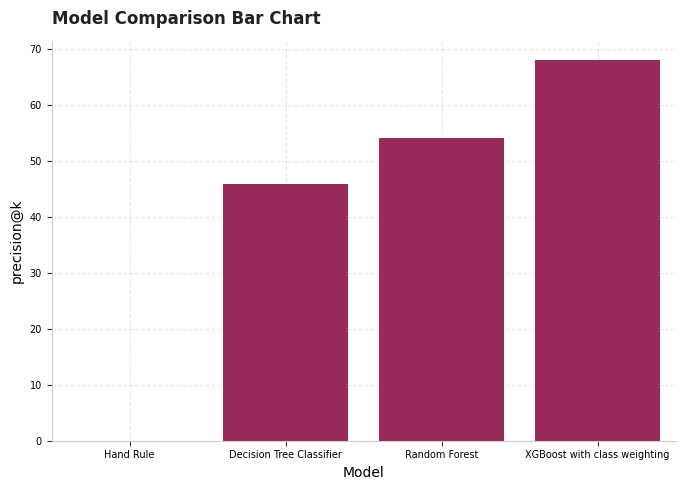

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
result_sum['precision_float']=result_sum['Precision@K'].str.replace('%','').astype(float)
fig,ax=plt.subplots(figsize=(7,5))
sns.barplot(x='Model',y='precision_float',data=result_sum,color='#AD1759')
ax.set(xlabel="Model", ylabel="precision@k")
ax.set_title('Model Comparison Bar Chart', loc='left',fontweight='bold', color='#222222', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_color('#cccccc')
ax.tick_params(axis='both', labelsize=7, color='#333333') 
ax.grid(True, axis='both', linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Precision@K comparison across all four approaches tested, a simple hand rule, a single Decision Tree, Random Forest, and the final weighted XGBoost model. The steady increase from **0.0% to 68.0%** visually confirms the Section 1 argument: a hand written rule failed to capture the pattern, while trained models especially the ensemble methods found real, usable signal in the data.

### Confusion Matrix Heat Map

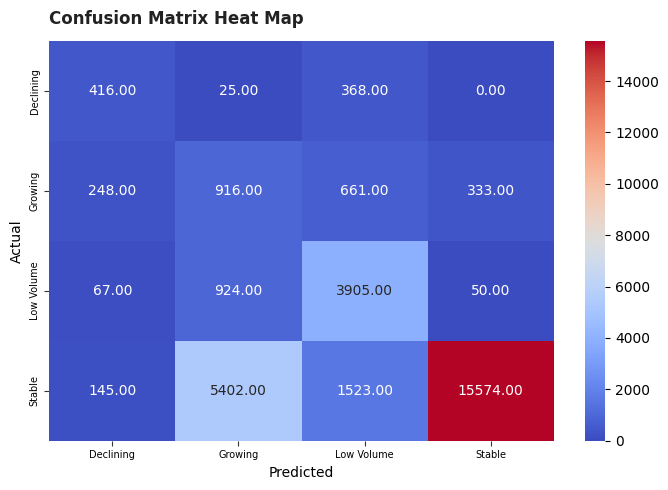

In [58]:
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(data=conf_matrix, annot=True, cmap='coolwarm',fmt='.2f',xticklabels=le.classes_ , yticklabels=le.classes_)
ax.set(xlabel="Predicted", ylabel="Actual")
ax.set_title('Confusion Matrix Heat Map', loc='left',fontweight='bold', color='#222222', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_color('#cccccc')
ax.tick_params(axis='both', labelsize=7, color='#333333') 
ax.grid(True, axis='both', linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Confusion matrix for the weighted XGBoost model in which rows are showing actual labels and columns are showing predicted labels.

### Label Distribution Chart

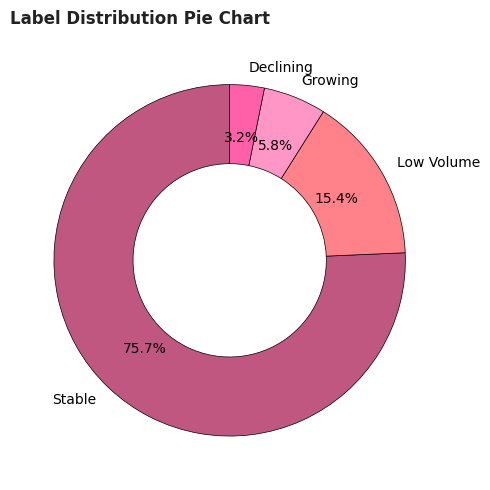

In [59]:
piiee=round(df_final['label'].value_counts()*100/len(df_final['label']),2)
p=pd.DataFrame(piiee).reset_index()
p=p.sort_values(by='count',ascending=False)
colors = ['#C05780', '#FF828B', '#FF96C5', '#FF60A8']
fig,ax=plt.subplots(figsize=(7,5))
plt.pie(p['count'],labels=p['label'],colors=colors,autopct='%1.1f%%',startangle=90,pctdistance=0.7,wedgeprops={'edgecolor': 'black', 'linewidth': 0.5,'width':0.45}, textprops={'fontsize':10,'color':'#000000'})
ax.set_title('Label Distribution Pie Chart',loc='left',fontweight='bold', color='#222222', pad=12)
plt.tight_layout()
plt.show()

Label distribution across all 331,436 pages where `Stable` dominates due to the large zero click page group, motivating the class imbalance handling in Section 4

## Reproducibility

All code for this project is available in the `work/notebooks/` folder of this repository, including the capstone notebook (`capstone.ipynb`) and the earlier weekly assignment notebooks it builds on. The analysis uses the `FlyRank/internship-warehouse` dataset (build v20260703) from Hugging Face, specifically the March and April 2026 partitions of `fact_content_daily_performance`. Running the notebook end to end requires a Hugging Face read token (set as an environment variable, `HF_TOKEN`) with access to the gated dataset. No client names, private URLs, or credentials are included anywhere in this repository.

## Acknowledgments & data credit

Built on the FlyRank ML Internship dataset: [flyrank.ai](https://flyrank.ai)

## Demo outline (5 minutes)

1. **The problem (30 sec):** Content teams don't know which pages are declining until traffic has already dropped. Show Section 1's question.
2. **The data (30 sec):** 9.9M rows of real page level search data, one mid panel month (March 2026) used to build features, April used to measure the actual outcome.
3. **The naive approach fails (1 min):** Show the model comparison bar chart, hand rule scores 0% precision@50. Explain why: zero impression pages were mostly already stable pages, not decliners.
4. **The models improve on it (1.5 min):** Walk through Decision Tree to Random Forest to XGBoost, precision climbing to 66%. Show the confusion matrix and explain the recall problem we found (missing half of real decliners).
5. **The fix (1 min):** In class weighting the recall jumps from 16% to 51%, precision also improves to 68%. Show the final results table.
6. **The output (30 sec):** Show the two ranked recommendation tables global top 50, and per client top 5 and explain why both exist (client size fairness).

## Social post

Spent the last few weeks building an ML model to predict which webpages are about to decline in search performance sing real, page level data from FlyRank's internship warehouse (9.9M rows).

The most useful part wasn't the model, it was the debugging. My hand written rule scored 0% precision. My first trained model looked good on paper (66% precision on its top picks) but was quietly missing 84% of all real declining pages. Found it, fixed it with class weighting, and ended up with a model that's both more precise AND catches 3x more real decliners.

Full writeup + code: 

## Employer facing summary

Built and evaluated a machine learning pipeline that predicts webpage traffic decline using real, page level search data (9.9M rows), comparing a rule based baseline against Decision Tree, Random Forest, and XGBoost models on a leakage aware, client grouped train/test split. Identified a class imbalance problem via confusion matrix analysis the initial model missed 84% of true declining pages despite looking accurate overall and resolved it with weighted training, improving recall from 16% to 51% while also improving precision. Delivered a ranked, decision support recommendation system designed for real content team workflows, with documented limitations and reproducible code.

## Self-check

Before you submit, confirm each line honestly:

- [ yes ] Every section above is filled — markdown thinking AND the code that backs it
- [ yes ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ yes ] No client names, URLs, or private queries anywhere
- [ yes ] My claims use careful words: observed, measured, directional, decision-support
- [ yes ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ yes ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ yes ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
